In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import scipy.spatial.distance as spd
import importlib

import plotly.express as px
import matplotlib.pyplot as plt

import utility_functions as uf

In [88]:
year = 2020
cap_prob = 0.03
cap_articles = 5000
mode_list = ["individual", "collaborative"]

In [89]:
df_cs_indiv = pd.read_csv(uf.PATH+"df_country_subfield/individual_{}.csv".format(year), index_col=0)
df_cs_collab = pd.read_csv(uf.PATH+"df_country_subfield/collaborative_{}.csv".format(year), index_col=0)

df_prob_indiv = df_cs_indiv.div(df_cs_indiv.sum(axis=1), axis=0)
df_prob_collab = df_cs_collab.div(df_cs_collab.sum(axis=1), axis=0)

df_prob_capped_indiv = uf.df_capped(df_prob_indiv, cap_prob, year)
df_prob_capped_collab = uf.df_capped(df_prob_collab, cap_prob, year)

# country_idx = df_cs_indiv.sum(axis=1).to_frame("total").query("total > @cap_articles").index.intersection(
#     df_cs_collab.sum(axis=1).to_frame("total").query("total > @cap_articles").index
# )

df_country_stats = pd.read_csv(uf.PATH+f"df_stats_country_yearly.csv", index_col=0)

In [90]:
df_stats = (
    pd.DataFrame(index=(df_cs_indiv.index.union(df_cs_collab.index)))
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "sub-region", "region"]], left_index=True, right_on="alpha-2")
    .rename(columns={"alpha-2": "country"})
    .set_index("country")
    .assign(
        total_indiv=df_cs_indiv.sum(axis=1),
        total_collab=df_cs_collab.sum(axis=1),
        log_total_indiv=lambda df: np.log(df.total_indiv),
        log_total_collab=lambda df: np.log(df.total_collab),
        gini_indiv= df_cs_indiv.apply(uf.gini, axis=1),
        gini_collab=df_cs_collab.apply(uf.gini, axis=1),
    )
)

In [94]:
uf.get_subfield_info(2730)

,subfield_id,subfield_name,field_name,domain_name
157,2730,Oncology,Medicine,Health Sciences


In [92]:
uf.df_topics[["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]].drop_duplicates()

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
0,1908,Geophysics,19,Earth and Planetary Sciences,3,Physical Sciences
1,3107,"Atomic and Molecular Physics, and Optics",31,Physics and Astronomy,3,Physical Sciences
2,1408,Strategy and Management,14,"Business, Management and Accounting",2,Social Sciences
3,1111,Soil Science,11,Agricultural and Biological Sciences,1,Life Sciences
4,2309,Nature and Landscape Conservation,23,Environmental Science,3,Physical Sciences
...,...,...,...,...,...,...
4129,2702,Anatomy,27,Medicine,4,Health Sciences
4322,2104,Nuclear Energy and Engineering,21,Energy,3,Physical Sciences
4422,2103,Fuel Technology,21,Energy,3,Physical Sciences
4440,2200,General Engineering,22,Engineering,3,Physical Sciences


In [93]:
country = "US"
df_profile_country = pd.concat([
    df_prob_indiv.loc[country].to_frame("indiv"), df_prob_collab.loc[country].to_frame("collab")
])
px.bar(df_profile_country, x=df_profile_country.index, y=["indiv", "collab"], barmode="overlay",
       title=f"National (individual) vs International (collaborative) profiles: {uf.id2name_country[country]}, {year}")

# Jaccard dissimilarity

$$
Jaccard(A, B) = 1 - \dfrac{|A \cap B|}{|A \cup B|}
$$

In [8]:
country = "ID"
eps = 0

In [9]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "jaccard"] = spd.jaccard(df_cs_collab.loc[c] > eps, df_cs_indiv.loc[c] > eps)
    else:
        df_stats.loc[c, "jaccard"] = 1

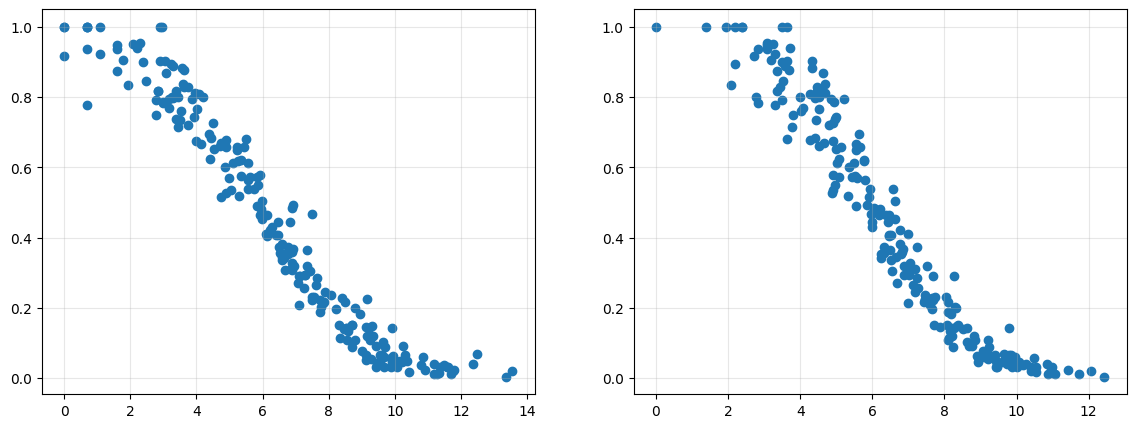

In [10]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols=2, figsize=(14, 5))

ax1.scatter(df_stats.log_total_indiv, df_stats.jaccard)
ax1.grid(alpha=0.3)

ax2.scatter(df_stats.log_total_collab, df_stats.jaccard)
ax2.grid(alpha=0.3)


In [11]:
# px.scatter(df_stats, x=["log_total_collab", "log_total_indiv"], y="jaccard", hover_data=["name", "region"], title="Jaccard vs N_articles")
# px.scatter(df_stats, x=["gini_collab", "gini_indiv"], y="jaccard", hover_data=["name", "region"], title="Jaccard vs N_articles")

In [12]:
# px.scatter(df_stats, x=["gini_collab", "gini_indiv"], y="jaccard", hover_data=["name", "region"], title="Jaccard vs N_articles")

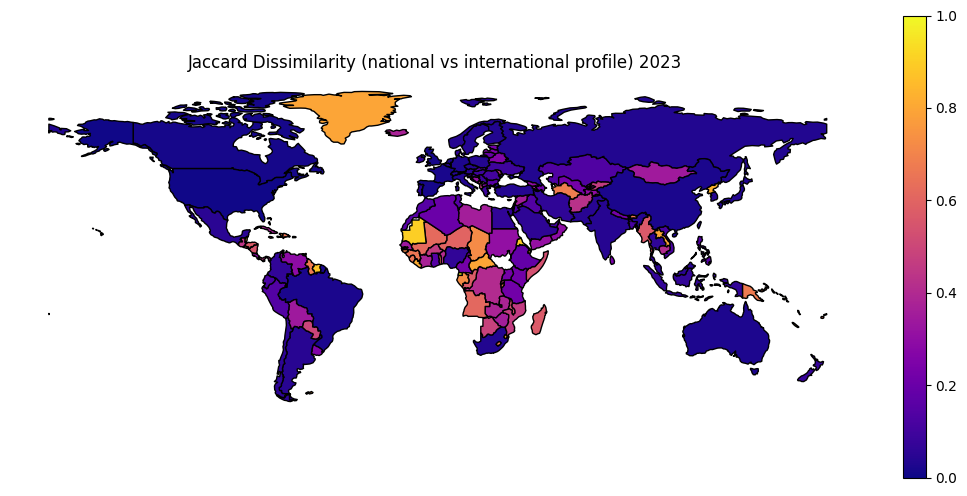

In [13]:
_, _ = uf.plot_map_continuous(df_stats, "jaccard", range=(0, 1), title=f"Jaccard Dissimilarity (national vs international profile) {year}")

In [14]:
def jaccard_turn(a, b):
    intersect = a == b
    outer_a = a[~intersect].sum()
    outer_b = b[~intersect].sum()
    return 2 * min(outer_a, outer_b) / (a[intersect].sum() + 2 * min(outer_a, outer_b))

In [15]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "jaccard_turn"] = jaccard_turn(df_cs_collab.loc[c] > eps, df_cs_indiv.loc[c] > eps)
    else:
        df_stats.loc[c, "jaccard_turn"] = 1

In [16]:
px.scatter(df_stats, x=["log_total_indiv", "log_total_collab"], y="jaccard_turn", hover_data=["name", "region"], title="Jaccard Turn vs N_articles")

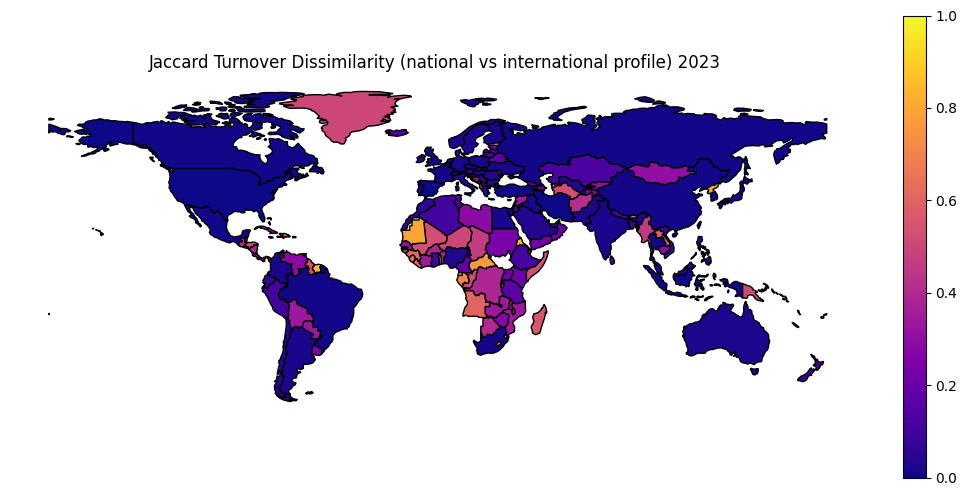

In [17]:
_, _ = uf.plot_map_continuous(df_stats, "jaccard_turn", range=(0, 1), title=f"Jaccard Turnover Dissimilarity (national vs international profile) {year}")

# Bray-Curtis



In [18]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "bray_curtis"] = spd.braycurtis(df_cs_collab.loc[c] > 0, df_cs_indiv.loc[c] > 0)
    else:
        df_stats.loc[c, "bray_curtis"] = 1

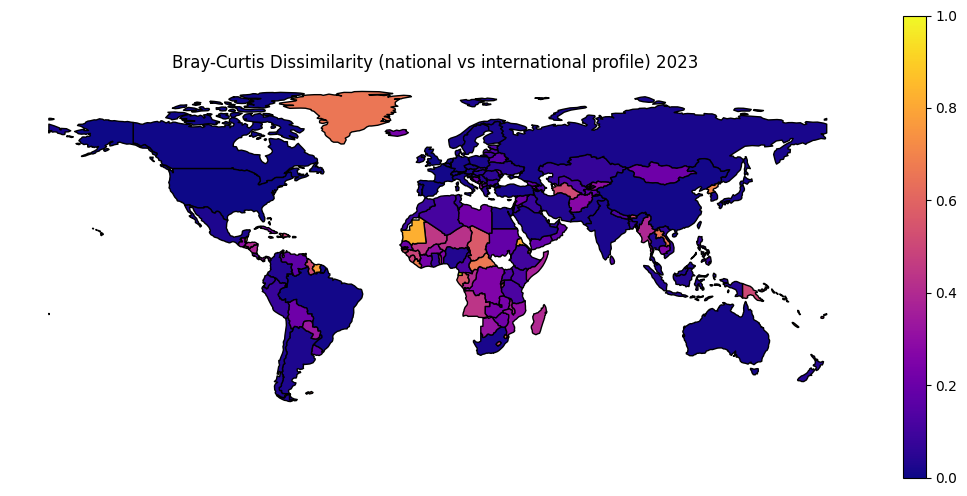

In [19]:
_, _ = uf.plot_map_continuous(df_stats, "bray_curtis", range=(0, 1), title=f"Bray-Curtis Dissimilarity (national vs international profile) {year}")

# Wasserstein-tree (probability)

In [20]:
w1_max = (
    uf.df_topics
    .sample(2)
)

subfield_tree = uf.get_subfield_tree(uf.df_topics)

# different subfield, fields, domains (maximum distance)
subfield1 = "2713"
subfield2 = "1904"
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

In [21]:
country = "US"

In [22]:
_, _, w1_dist = uf.get_dist_w1_tree(subfield_tree, df_prob_collab.loc[country].dropna().to_dict(), df_prob_indiv.loc[country].dropna().to_dict())

In [23]:
cap = 0.03
subfield1 = "2713"
subfield2 = "1904"

labels = df_prob_indiv.columns.astype(str)
values = (1 - cap) / len(labels) * np.ones(len(labels))

dict1 = dict(zip(labels, values))
dict2 = dict(zip(labels, values))
dict1[subfield1] = cap
dict2[subfield2] = cap
_, _, w1_max_capped = uf.get_dist_w1_tree(subfield_tree, dict1, dict2)

# df_dist_capped = uf.get_w1_distances(subfield_tree, df_prob_capped, w1_max)
# np.fill_diagonal(df_dist_capped.values, np.nan)

In [24]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        _, _, df_stats.loc[c, "w1_tree"] = (uf.get_dist_w1_tree(subfield_tree, df_prob_collab.loc[c].dropna().to_dict(), df_prob_indiv.loc[c].dropna().to_dict())
                                            / w1_max)
        _, _, df_stats.loc[c, "w1_tree_capped"] = (uf.get_dist_w1_tree(subfield_tree, df_prob_capped_collab.loc[c].dropna().to_dict(), df_prob_capped_indiv.loc[c].dropna().to_dict())
                                            )
    else:
        df_stats.loc[c, "w1_tree"] = np.nan
        df_stats.loc[c, "w1_tree_capped"] = np.nan
df_stats.w1_tree_capped = df_stats.w1_tree_capped / df_stats.w1_tree_capped.max()

In [25]:
df_stats.query("total_indiv >= @cap_articles")[["total_indiv", "total_collab", "gini_indiv", "gini_collab", "w1_tree", "w1_tree_capped"]].corr()

,total_indiv,total_collab,gini_indiv,gini_collab,w1_tree,w1_tree_capped
total_indiv,1.000000,0.856634,0.312501,0.307735,-0.278182,0.018316
total_collab,0.856634,1.000000,0.041564,0.244573,-0.222401,-0.043475
gini_indiv,0.312501,0.041564,1.000000,0.346279,0.142542,0.152291
gini_collab,0.307735,0.244573,0.346279,1.000000,-0.072098,-0.206555
w1_tree,-0.278182,-0.222401,0.142542,-0.072098,1.000000,0.126576
w1_tree_capped,0.018316,-0.043475,0.152291,-0.206555,0.126576,1.000000


In [26]:
df_stats[["total_indiv", "total_collab", "gini_indiv", "gini_collab", "w1_tree", "w1_tree_capped"]].corr()

,total_indiv,total_collab,gini_indiv,gini_collab,w1_tree,w1_tree_capped
total_indiv,1.000000,0.873929,0.230050,0.243694,-0.172923,-0.010247
total_collab,0.873929,1.000000,0.266878,0.310585,-0.199311,-0.073259
gini_indiv,0.230050,0.266878,1.000000,0.801788,-0.459471,-0.188019
gini_collab,0.243694,0.310585,0.801788,1.000000,-0.534931,-0.218760
w1_tree,-0.172923,-0.199311,-0.459471,-0.534931,1.000000,0.252402
w1_tree_capped,-0.010247,-0.073259,-0.188019,-0.218760,0.252402,1.000000


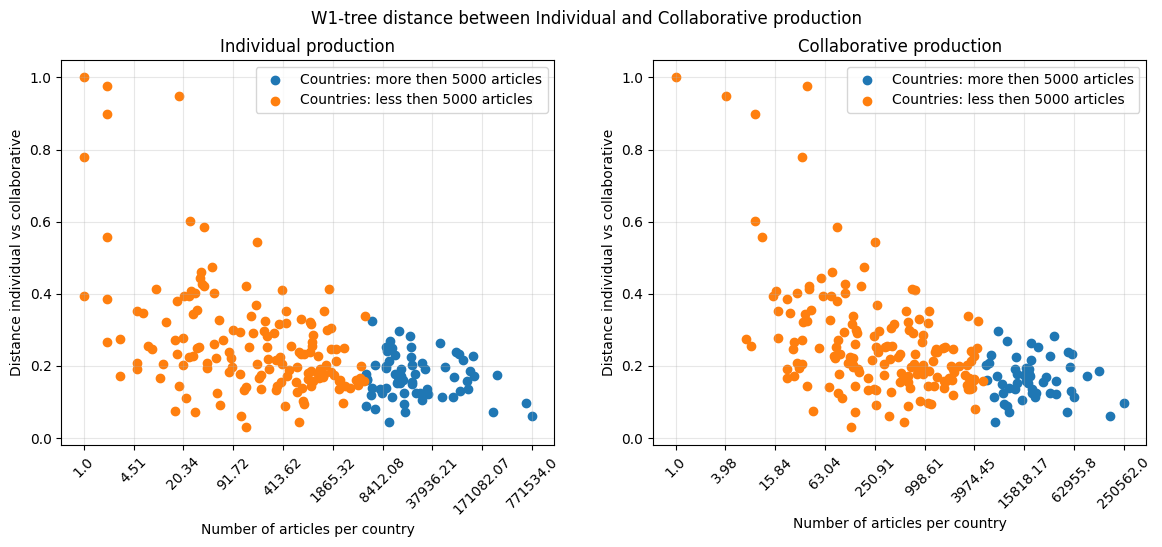

In [62]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols=2, figsize=(14, 5))

ax1.scatter(df_stats.query("total_indiv >= @cap_articles").log_total_indiv, df_stats.query("total_indiv >= @cap_articles").w1_tree, label=f"Countries: more then {cap_articles} articles")
ax1.scatter(df_stats.query("total_indiv < @cap_articles").log_total_indiv, df_stats.query("total_indiv < @cap_articles").w1_tree, label=f"Countries: less then {cap_articles} articles")

ax1.legend()

ticks = np.linspace(0, df_stats.log_total_indiv.max(), 10)
ax1.set_xticks(ticks)
ax1.set_xticklabels(np.round(np.exp(ticks), 2))
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Number of articles per country")
ax1.set_ylabel("Distance individual vs collaborative")
ax1.set_title("Individual production")

ax1.grid(alpha=0.3)

ax2.scatter(df_stats.query("total_collab >= @cap_articles").log_total_collab, df_stats.query("total_collab >= @cap_articles").w1_tree, label=f"Countries: more then {cap_articles} articles")
ax2.scatter(df_stats.query("total_collab < @cap_articles").log_total_collab, df_stats.query("total_collab < @cap_articles").w1_tree, label=f"Countries: less then {cap_articles} articles")
ax2.grid(alpha=0.3)

ax2.legend()

ticks = np.linspace(0, df_stats.log_total_collab.max(), 10)
ax2.set_xticks(ticks)
ax2.set_xticklabels(np.round(np.exp(ticks), 2))
ax2.tick_params(axis='x', rotation=45)
ax2.set_xlabel("Number of articles per country")
ax2.set_ylabel("Distance individual vs collaborative")
ax2.set_title("Collaborative production")

_ = plt.suptitle("W1-tree distance between Individual and Collaborative production")

In [45]:
# px.scatter(df_stats,
#            x="log_total_indiv",
#            y=["w1_tree", "w1_tree_capped"],
#            hover_data=["name"],
#            title=f"W1-tree vs N_articles ({year})",
#            labels={"value": "Log(Total Articles)", "w1_tree": "W1-tree distance"})

In [154]:
# px.scatter(df_stats,
#            x=["gini_collab", "gini_indiv"],
#            y="w1_tree",
#            hover_data=["name"],
#            title=f"W1-tree vs N_articles ({year})",
#            labels={"value": "Log(Total Articles)", "w1_tree": "W1-tree distance"})

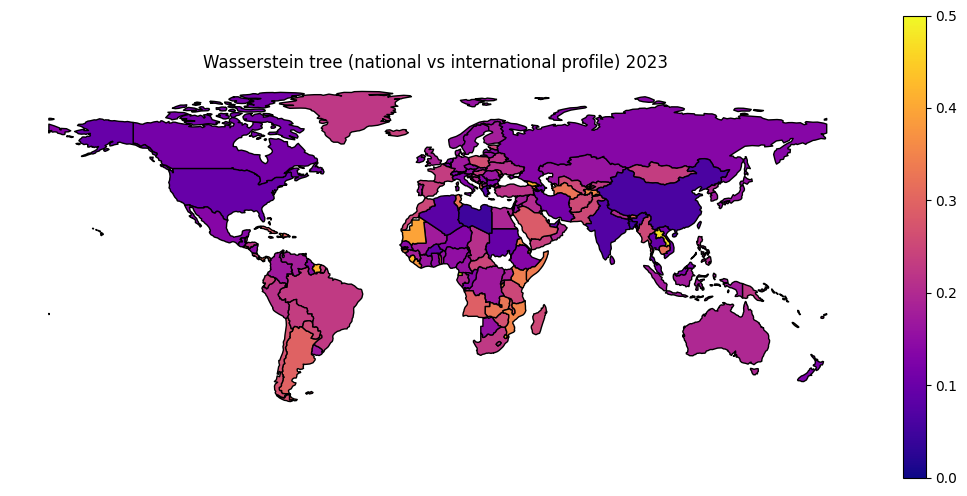

In [48]:
_, _ = uf.plot_map_continuous(df_stats, "w1_tree", title=f"Wasserstein tree (national vs international profile) {year}", range=(0, 0.5))

In [157]:
# px.histogram(df_stats, x="w1_tree", nbins=50)

# Cosine

In [37]:
df_global = pd.read_csv(uf.PATH+"df_stats_subfields_global_yearly.csv").query("year == @year")
df_global.subfield_id = df_global.subfield_id.astype(int)
df_global = (
    df_global
    .set_index("subfield_id")
    .assign(
        z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
        z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
    )
)


In [38]:
df_im_collab = np.log(df_prob_collab.div(df_global["probability_collab"].values, axis="columns"))
df_im_indiv = np.log(df_prob_indiv.div(df_global["probability_individual"].values, axis="columns"))

In [39]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "cosine_0"] = min(spd.cosine(df_im_collab.loc[c].fillna(0), df_im_indiv.loc[c].fillna(0)), 1)
    else:
        df_stats.loc[c, "cosine_0"] = np.nan

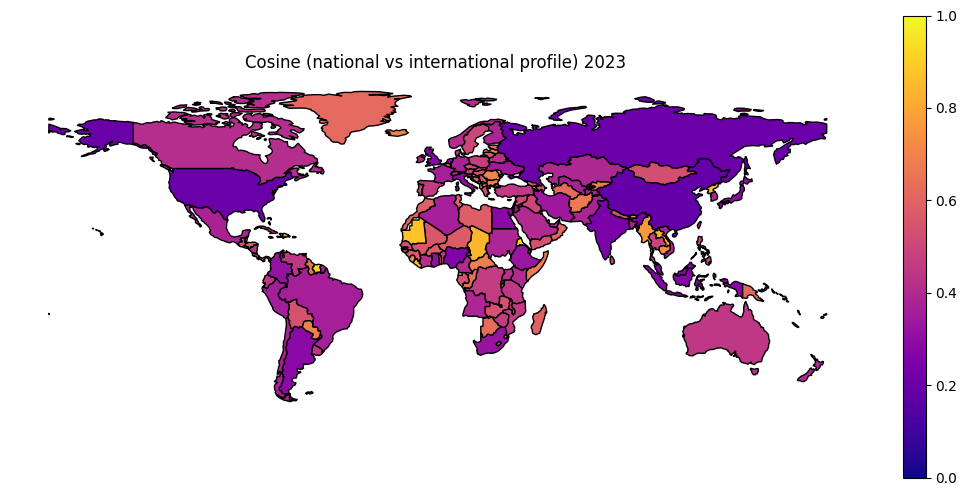

In [40]:
_, _ = uf.plot_map_continuous(df_stats, "cosine_0", title=f"Cosine (national vs international profile) {year}", range=(0, 1))

# Compare boxplots

In [53]:
metrics = ["jaccard", "w1_tree", "w1_tree_capped"]

In [63]:
df_stats.query("total_indiv >= @cap_articles")[metrics].corr()

,jaccard,w1_tree,w1_tree_capped
jaccard,1.000000,0.388816,-0.061647
w1_tree,0.388816,1.000000,0.110519
w1_tree_capped,-0.061647,0.110519,1.000000


In [54]:
df_stats[metrics].corr()

,jaccard,w1_tree,w1_tree_capped
jaccard,1.000000,0.540447,0.222443
w1_tree,0.540447,1.000000,0.252402
w1_tree_capped,0.222443,0.252402,1.000000


In [64]:
df_box = (
    df_stats
    .reset_index()
    .melt(id_vars=["country", "alpha-3", "name", "region"], var_name="metric", value_vars=metrics, value_name="value")
)

px.box(
    df_box,
    x="metric",
    y="value",
    points="all",
    hover_data=["country", "name", "region"],
    title="Dissimilarity measurement comparison: 0 -- the same, 1 -- distant",
    color="metric"
)

In [65]:
metric = ["w1_tree", "jaccard"]
px.bar(df_stats.sort_values(metric).reset_index(), x="alpha-3", y=metric, hover_data=["country", "alpha-3", "name", "region"], barmode="group")

In [66]:
country = "ID"
df_profile_country = pd.concat([
    df_prob_indiv.loc[country].to_frame("indiv"), df_prob_collab.loc[country].to_frame("collab")
])
px.bar(df_profile_country, x=df_profile_country.index, y=["indiv", "collab"], barmode="overlay")

In [67]:
country = "IN"
df_profile_country = pd.concat([
    df_prob_indiv.loc[country].to_frame("indiv"), df_prob_collab.loc[country].to_frame("collab")
])
px.bar(df_profile_country, x=df_profile_country.index, y=["indiv", "collab"], barmode="overlay")

# Compare global

In [68]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_global = pd.read_csv(uf.PATH+"df_stats_subfields_global_yearly.csv").query("year == @year")
df_global.subfield_id = df_global.subfield_id.astype(int)
df_global = (
    df_global
    .set_index("subfield_id")
    .assign(
        z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
        z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
    )
)

In [69]:
_, _, _ = uf.get_dist_w1_tree(subfield_tree,
                    df_global.reset_index("subfield_id").assign(subfield_str=lambda df: df.subfield_id.astype(str)).set_index("subfield_str").probability_individual.dropna().to_dict(),
                    df_global.reset_index("subfield_id").assign(subfield_str=lambda df: df.subfield_id.astype(str)).set_index("subfield_str").probability_collab.dropna().to_dict())

In [69]:
# px.bar(df_global, x=df_global.index.astype(str), y=["probability_individual", "probability_collab"], barmode="overlay")

# Compare local to global

In [72]:
global_dict_indiv = (
    df_global
    .reset_index("subfield_id")
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    .set_index("subfield_str")
    .probability_individual
    .dropna()
    .to_dict()
)
global_dict_collab = (
    df_global
    .reset_index("subfield_id")
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    .set_index("subfield_str")
    .probability_collab
    .dropna()
    .to_dict()
)

In [52]:
importlib.reload(uf)

<module 'irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/irina/utility_functions.py'>

In [73]:
# different subfield, fields, domains (maximum distance)
subfield1 = "2713"
subfield2 = "1904"
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

uf.get_jaccard(df_stats, df_cs_collab, df_global, col_name="jaccard_gl_collab", col_df2="counts_collab")
uf.get_jaccard(df_stats, df_cs_indiv, df_global, col_name="jaccard_gl_indiv", col_df2="counts_individual")

uf.get_w1_tree(df=df_stats, subfield_tree=subfield_tree, df1=df_prob_collab, dict2=global_dict_collab, col_name="w1_tree_gl_collab")
uf.get_w1_tree(df=df_stats, subfield_tree=subfield_tree, df1=df_prob_indiv, dict2=global_dict_indiv, col_name="w1_tree_gl_indiv", w1_max=w1_max)

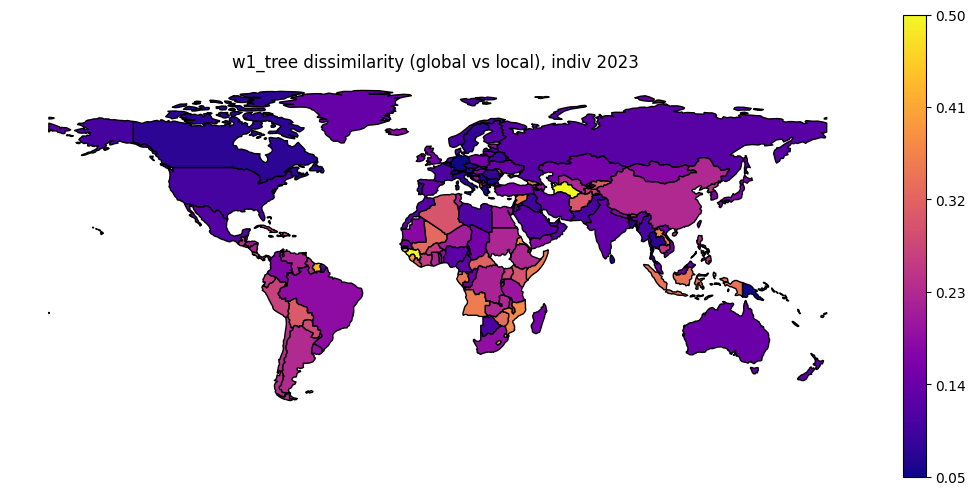

In [ ]:
mode = "w1_tree"
regime = "indiv"
_, _ = uf.plot_map_continuous(df_stats, f"{mode}_gl_{regime}",
                              title=f"{mode} dissimilarity (global vs local), {regime} {year}",
                              range=(0.05, 0.5))

In [77]:
df_box_gl = (df_stats.reset_index().melt(id_vars=["country", "alpha-3", "name", "region"],
                                         var_name="metric",
                                         value_vars=["w1_tree_gl_indiv", "w1_tree_gl_collab", "jaccard_gl_collab", "jaccard_gl_indiv"], value_name="value"))

In [78]:
px.box(
    df_box_gl,
    x="metric",
    y="value",
    points="all",
    hover_data=["alpha-3", "name", "region"],
    color="metric",
    title="Dissimilarity comparison: local vs global"
)

# Pipeline yearly



In [70]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [63]:
start_year = 1970
end_year = 2023

subfield1 = "2713"
subfield2 = "1904"

subfield_tree = uf.get_subfield_tree(uf.df_topics)
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

df_stats_list = []
for year_loop in range(start_year, end_year+1):
    try:
        df_cs_indiv_loop = pd.read_csv(uf.PATH+"df_country_subfield/individual_{}.csv".format(year_loop), index_col=0)
        df_cs_collab_loop = pd.read_csv(uf.PATH+"df_country_subfield/collaborative_{}.csv".format(year_loop), index_col=0)

        all_cols = df_cs_indiv_loop.columns.union(df_cs_collab_loop.columns)

        df_cs_collab_loop = df_cs_collab_loop.reindex(columns=all_cols)
        df_cs_indiv_loop = df_cs_indiv_loop.reindex(columns=all_cols)

        df_global_loop = pd.read_csv(uf.PATH+"df_global_comparison_yearly.csv").drop_duplicates().query("year == @year_loop")
        df_global_loop.subfield_id = df_global_loop.subfield_id.astype(int)
        df_global_loop = (
            df_global_loop
            .set_index("subfield_id")
            .assign(
                z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
                z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
            )
        )

        global_dict_indiv_loop = (
        df_global_loop
        .reset_index("subfield_id")
        .assign(subfield_str=lambda df: df.subfield_id.astype(str))
        .set_index("subfield_str")
        .probability_individual
        .dropna()
        .to_dict()
        )
        global_dict_collab_loop = (
            df_global_loop
            .reset_index("subfield_id")
            .assign(subfield_str=lambda df: df.subfield_id.astype(str))
            .set_index("subfield_str")
            .probability_collab
            .dropna()
            .to_dict()
        )

        df_prob_collab_loop = df_cs_collab_loop.div(df_cs_collab_loop.sum(axis=1), axis=0)
        df_prob_indiv_loop = df_cs_indiv_loop.div(df_cs_indiv_loop.sum(axis=1), axis=0)

        df_stats_loop = (
            pd.DataFrame(index=(df_cs_indiv_loop.index.union(df_cs_collab_loop.index)))
            .merge(uf.df_country[["alpha-2", "alpha-3", "name", "region"]], left_index=True, right_on="alpha-2")
            .rename(columns={"alpha-2": "country"})
            .set_index("country")
            .assign(year=year_loop)
        )

        uf.get_jaccard(df_stats_loop, df_cs_collab_loop, df_cs_indiv_loop, col_name="jaccard")
        uf.get_jaccard(df_stats_loop, df_cs_collab_loop, df_global_loop, col_name="jaccard_gl_collab", col_df2="counts_collab")
        uf.get_jaccard(df_stats_loop, df_cs_indiv_loop, df_global_loop, col_name="jaccard_gl_indiv", col_df2="counts_individual")

        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_collab_loop, df2=df_prob_indiv_loop, col_name="w1_tree", w1_max=w1_max)
        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_collab_loop, dict2=global_dict_collab_loop, col_name="w1_tree_gl_collab", w1_max=w1_max)
        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_indiv_loop, dict2=global_dict_indiv_loop, col_name="w1_tree_gl_indiv", w1_max=w1_max)

        df_stats_list.append(df_stats_loop)
    except Exception as e:
        print(year_loop, e)

KeyboardInterrupt: 

In [22]:
# pd.concat(df_stats_list).reset_index().to_csv(uf.PATH+"df_stats_national_international_1970_2023.csv", index=False)

In [23]:
df_stats_dyn = pd.concat(df_stats_list).reset_index()

In [ ]:
# start_year = 1970
# end_year = 2023
# year_list = range(start_year, end_year+1)
#
# mode_list = ["individual", "collaborative"]
#
# df_prob_yearly_list = []
#
#
# for year_loop in year_list:
#     for mode_loop in mode_list:
#         df_tmp = pd.read_csv(uf.PATH+f"df_country_subfield/{mode_loop}_{year_loop}.csv", index_col=0)
#         df_prob_yearly_list.append(
#             df_tmp.div(df_tmp.sum(axis=1), axis=0).reset_index().assign(year=year_loop, mode=mode_loop)
#         )
#
# df_prob_yearly = pd.concat(df_prob_yearly_list)

In [14]:
# df_prob_yearly.to_csv(uf.PATH+f"df_prob_yearly.csv", index=False)

# Demonstration yearly

In [71]:
df_stats_dyn = pd.read_csv(uf.PATH+"df_stats_dist_nat_intern_yearly.csv")
df_prob_yearly = pd.read_csv(uf.PATH+"df_prob_yearly.csv")

In [72]:
country_list = ["US", "FR", "CN", "CH", "IN", "ID", "AU", "BR", "RU"]

In [75]:
df_stats_dyn

,country,alpha-3,name,region,year,jaccard,jaccard_gl_collab,jaccard_gl_indiv,w1_tree,w1_tree_gl_collab,w1_tree_gl_indiv
0,AE,ARE,United Arab Emirates,Asia,1970,0.851852,0.959641,0.912351,0.186433,0.528105,0.428912
1,AF,AFG,Afghanistan,Asia,1970,1.000000,0.995516,0.980080,1.000000,0.900473,0.395001
2,AG,ATG,Antigua and Barbuda,Americas,1970,1.000000,0.995516,1.000000,1.000000,0.819316,1.000000
3,AL,ALB,Albania,Europe,1970,1.000000,0.995516,1.000000,1.000000,0.804213,1.000000
4,AM,ARM,Armenia,Asia,1970,0.928571,0.959641,0.856574,0.331809,0.284871,0.229955
...,...,...,...,...,...,...,...,...,...,...,...
10800,WS,WSM,Samoa,Oceania,2023,0.846154,0.916667,0.964286,0.320659,0.403750,0.525891
10801,YE,YEM,Yemen,Asia,2023,0.309645,0.293651,0.384921,0.237864,0.056800,0.176838
10802,ZA,ZAF,South Africa,Africa,2023,0.033058,0.067460,0.043651,0.225471,0.082131,0.186722
10803,ZM,ZMB,Zambia,Africa,2023,0.382022,0.404762,0.452381,0.329917,0.308354,0.225940


In [81]:
countries = df_stats.query("total_indiv >= @cap_articles").loc[country_list].index.to_list()
countries
# .country.to_list()

['US', 'FR', 'CN', 'CH', 'IN', 'ID', 'AU', 'BR', 'RU']

In [82]:
fig = px.box(
    (
        df_stats_dyn
        .query("country in @countries")
        # .query("year > @test_year")
    ),
    x="year",
    y="jaccard",
    points="outliers",
    hover_data=["country"],
    title="Jaccard dissimilarity between national and international profiles"
    # color="region"
)
fig.update_traces(
    marker=dict(color="grey"),
    line=dict(color="grey"),
    opacity=0.5
)
for country in country_list:
    fig.add_scatter(
        x=df_stats_dyn.query("country == @country").year,
        y=df_stats_dyn.query("country == @country").jaccard,
        mode="lines",
        name=country,
        # line=dict(width=3)
    )
fig.show()
# fig.write_image("../images/w1_tree_box_1970_2023.png",
#                 width=1200, height=600, scale=2)

In [83]:
fig = px.box(
    (
        df_stats_dyn
        # .query("year > @test_year")
        .query("country in @countries")
    ),
    x="year",
    y="w1_tree",
    points="outliers",
    hover_data=["country"],
    title="W1-tree Distance between national and international profiles",

    # color="grey"
)
fig.update_traces(
    marker=dict(color="grey"),
    line=dict(color="grey"),
    opacity=0.7
)
for country in country_list:
    fig.add_scatter(
        x=df_stats_dyn.query("country == @country").year,
        y=df_stats_dyn.query("country == @country").w1_tree,
        mode="lines",
        name=country,
        # line=dict(width=3)
    )
fig.show()
# fig.write_image("../images/w1_tree_box_1970_2023.png",
#                 width=1200, height=600, scale=2)

# Details examples

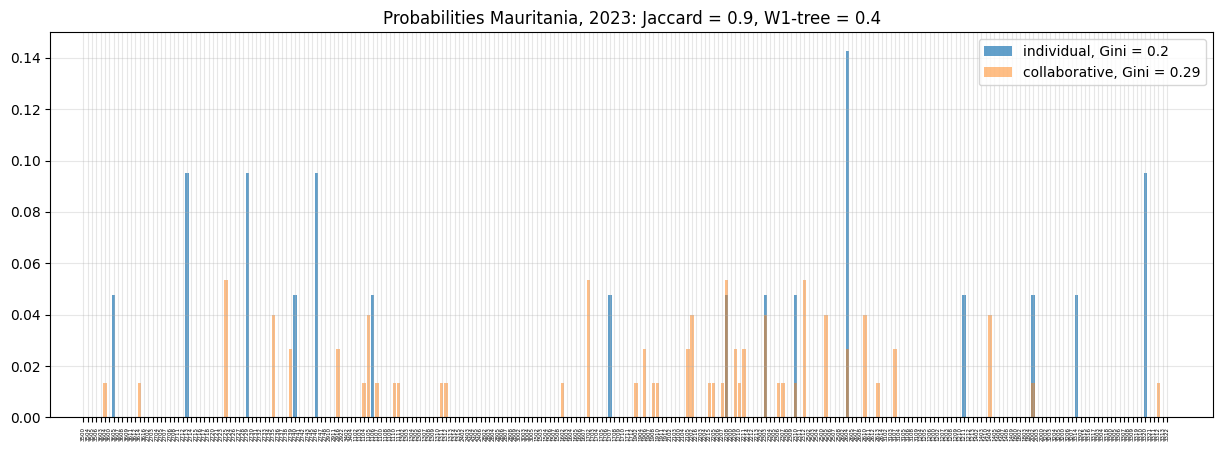

In [88]:
country = "US" # small Jaccard, small W1
# country = "TN" # small Jaccard, relatively big W1
country="MR" # big Jaccard, relatively big W1
# country = "ST" # relatively big Jaccard small W1
# country="GE" # big W1
# country = "TV" # J=1, W1=1
# country = "AW" # big Jaccard (1), big W1
year = 2023

jaccard = df_stats_dyn.set_index(["country", "year"]).loc[(country, year), "jaccard"]
w1_tree = df_stats_dyn.set_index(["country", "year"]).loc[(country, year), "w1_tree"]

df_plot = (
    df_prob_yearly
    .query(f"country == @country and year == @year")
    .drop(["year", "country"], axis=1)
    .set_index("mode")
    .T
    .assign(subfield_id=lambda df: df.index.astype(int))
    .merge(uf.df_topics[["subfield_id", "subfield_name", "field_name", "domain_name"]].drop_duplicates(), on="subfield_id", how="left")
    .sort_values(["domain_name", "field_name", "subfield_name"])
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    [["individual", "collaborative", "subfield_str"]]
    .set_index("subfield_str")
    .T
)

plt.subplots(figsize=[15, 5])
plt.bar(df_plot.columns,
        df_plot.loc[mode_list[0]], alpha=0.7, label=f"{mode_list[0]}, Gini = {round(uf.gini(df_plot.loc[mode_list[0]]), 2)}")
plt.bar(df_plot.columns,
        df_plot.loc[mode_list[1]], alpha=0.5, label=f"{mode_list[1]}, Gini = {round(uf.gini(df_plot.loc[mode_list[1]]), 2)}")
plt.xticks(rotation=90, fontsize=4)
plt.legend()
plt.title(f"Probabilities {uf.id2name_country[country]}, {year}: Jaccard = {round(jaccard, 2)}, W1-tree = {round(w1_tree, 2)}")
plt.grid(alpha=0.3)
plt.show()

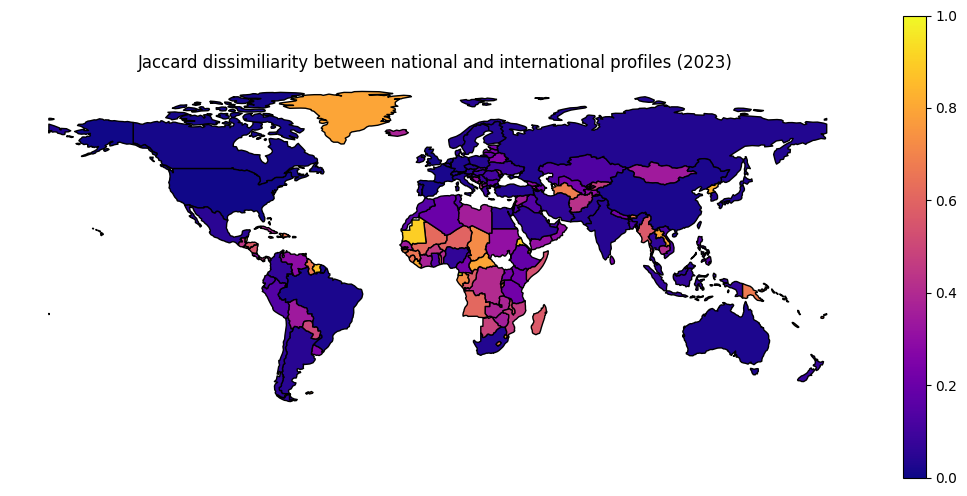

In [89]:
year = 2023
fig, ax = uf.plot_map_continuous((
    df_stats_dyn
    .query("year == @year")
), "jaccard", range = (0, 1), title=f"Jaccard dissimiliarity between national and international profiles ({year})"
)
# fig.savefig(f"../images/map_w1_tree_{year}.png")

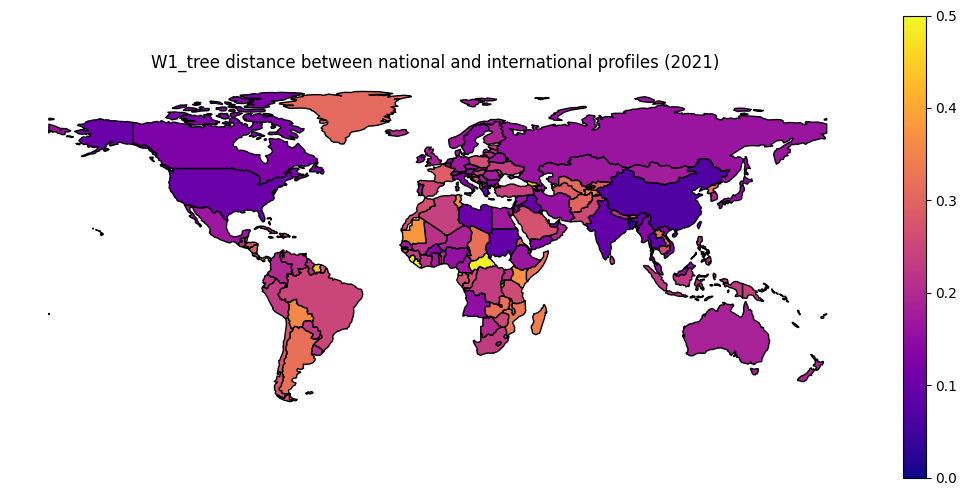

In [90]:
year = 2021
fig, ax = uf.plot_map_continuous((
    df_stats_dyn
    .query("year == @year")
), "w1_tree", range = (0, 0.5), title=f"W1_tree distance between national and international profiles ({year})"
)
# fig.savefig(f"../images/map_w1_tree_{year}.png")